# MEC 2026 - Online Music Alignment with Matchmaker (Audio)

**Music Alignment Workshop, MEC 2026 — Section 3 (Online Alignment), Part 1 (Audio)**

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pymatchmaker/mec2026_alignment_workshop/blob/online-alignment/notebooks/online_alignment_audio.ipynb)

This notebook accompanies the online alignment section of **Music Alignment Uncovered: Representations, Algorithms and Hands-On Tools** at MEC 2026.

In this notebook we align **one audio recording and the corresponding score** using the [Matchmaker](https://github.com/pymatchmaker/matchmaker). 

## 0. Setup

Run the setup cells once at the beginning. If you already installed the dependencies, you may skip the installation cells.

Workshop resources live under `mec-variation/` at the repo root. Make sure that directory is present alongside this notebook (clone the workshop repo if you haven't).

For audio score following, Matchmaker may need FluidSynth and libsndfile. In Colab the apt cell below installs them; locally install them via your system package manager, e.g. `conda install -c conda-forge fluidsynth libsndfile`.

In [16]:
# Colab-only system dependencies.
# Local users can install these separately, e.g.:
# conda install -c conda-forge fluidsynth libsndfile

import importlib.util
import shutil
import subprocess

try:
    IN_COLAB = importlib.util.find_spec("google.colab") is not None
except ModuleNotFoundError:
    IN_COLAB = False

if IN_COLAB and shutil.which("apt-get") is not None:
    subprocess.run(["apt-get", "update", "-qq"], check=True)
    subprocess.run(
        ["apt-get", "install", "-y", "-qq", "fluidsynth", "libsndfile1"],
        check=True,
    )
else:
    print("Skipping apt-get setup outside Colab.")

Skipping apt-get setup outside Colab.


In [17]:
# Python dependencies.
# pymatchmaker pulls in the main alignment stack; the other packages are used
# directly in this notebook for plotting, data inspection, and audio features.

%pip install -q "setuptools>=80,<81" "numpy>=1.26.3,<2.0" pymatchmaker pandas matplotlib librosa partitura ipython

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import json
import warnings
import librosa
import matchmaker
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import partitura as pt
from IPython.display import Audio, Image, display
from pathlib import Path
from matchmaker import Matchmaker
from matchmaker.features.audio import ChromagramProcessor, CQTProcessor, CQTSpectralFluxProcessor
from matchmaker.features.midi import onset_pianoroll
from matchmaker.matchmaker import AVAILABLE_METHODS, DEFAULT_METHOD, DEFAULT_PROCESSOR

warnings.filterwarnings("ignore", category=np.exceptions.ComplexWarning)
print("matchmaker", matchmaker.__version__)

In [ ]:
DATA_DIR = Path("../mec-variation")
SCORE_FILE = DATA_DIR / "scores/musicxml/short.musicxml"
AUDIO_FILE = DATA_DIR / "performances/wav/short1.wav"
MIDI_FILE = DATA_DIR / "performances/midi/short1.mid"
MATCH_FILE = DATA_DIR / "alignments/match/short1.match"
SNIPPET_FILE = DATA_DIR / "performances/wav/snippet.wav"
PREVIEW_IMAGE = DATA_DIR / "scores/simple_mozart_first_two_measures.png"

# Ground-truth note onsets (seconds) from the .match file.
NOTE_ANNOTATIONS = pt.load_match(str(MATCH_FILE))[0].note_array()["onset_sec"]

print("Data directory:", DATA_DIR.resolve())
for path in [SCORE_FILE, AUDIO_FILE, MIDI_FILE, MATCH_FILE, SNIPPET_FILE, PREVIEW_IMAGE]:
    print(path.name, "ok" if path.exists() else "missing")
print(f"NOTE_ANNOTATIONS: {len(NOTE_ANNOTATIONS)} note onsets from {MATCH_FILE.name}")

The recording below is the audio we will align against the score throughout the rest of this notebook (`short1.wav`, a take of the first 24 measures of Mozart K.265 var. 1). Every method we run from here on uses this same file as the performance input.

<audio controls src="../mec-variation/performances/wav/short1.wav"></audio> 

The Matchmaker pipeline keeps the same shape for both input types; the differences above are absorbed by the choice of `Stream` and `Processor`:

```text
input source -> Stream        -> Processor -> OnlineAlignment -> current score position
(audio/MIDI)   (file or live)   (features)    (method)           (beat position)
```

## 1. Difference between online vs. offline alignment

**Offline alignment** receives the complete performance before it computes the alignment. It can revise earlier decisions because it can see the future.

**Online alignment** receives a stream of observations. At each audio frame or MIDI event, it must estimate the current score position using only the past and present. The next estimate may step back to an earlier score position, but each estimate, once emitted, is final. Past outputs cannot be revised.

Technical constraints:

- Causality: no access to future observations.
- Latency: useful systems must react within tens of ms.

Online-specific challenges (vs offline)

- Ambiguity: repeated or harmonically similar passages can look alike locally.
- Drift & no recovery: locally-confused frames can't be revised, so errors compound over long pieces.
- Abrupt tempo changes: hard to catch up since a global cost search (which offline DTW would use) is not available.
- Noisy input: even during musically silent passages, the audio signal is not literally zero. Microphone hiss, room tone, breath, page turns, and non-instrument sounds all leak in and can confuse the feature stream. MIDI can also contain missing, extra, or mistimed notes.

Audio-specific challenges (vs MIDI)

- Polyphonic ambiguity: simultaneously-sounding notes share spectral bins, so per-frame pitch is uncertain.
- Onset uncertainty: onsets are smeared across the analysis window rather than landing on discrete event times. To compensate, audio-based score followers often design features to be onset-aware (e.g. by mixing harmonic features with a spectral-flux or onset-strength signal).
- Timbre & recording variation: instrument, microphone, room change the spectrogram; score-synthesized templates never match the performance exactly.
- Latency floor: audio features need an analysis window wider than the hop length, so each frame depends on a short future window. Pure MIDI followers do not have this inherent delay.

## 2. Audio Features

Matchmaker doesn't feed raw audio samples into the score follower. The `AudioStream` slices the source into fixed-size hops, and each hop goes through a `Processor` that returns one feature vector.

Two processors used in this workshop:

- `ChromagramProcessor` — 12-bin chroma. Default for audio, used by the Arzt OLTW method.
- `CQTProcessor` — 88-bin constant-Q transform. Used by the OuterHMM method.

Below we run these processors hop-by-hop on a short snippet and render the feature image one column at a time.

Below is the short score snippet for feature visualization, along with the audio snippet (first 2 measures).


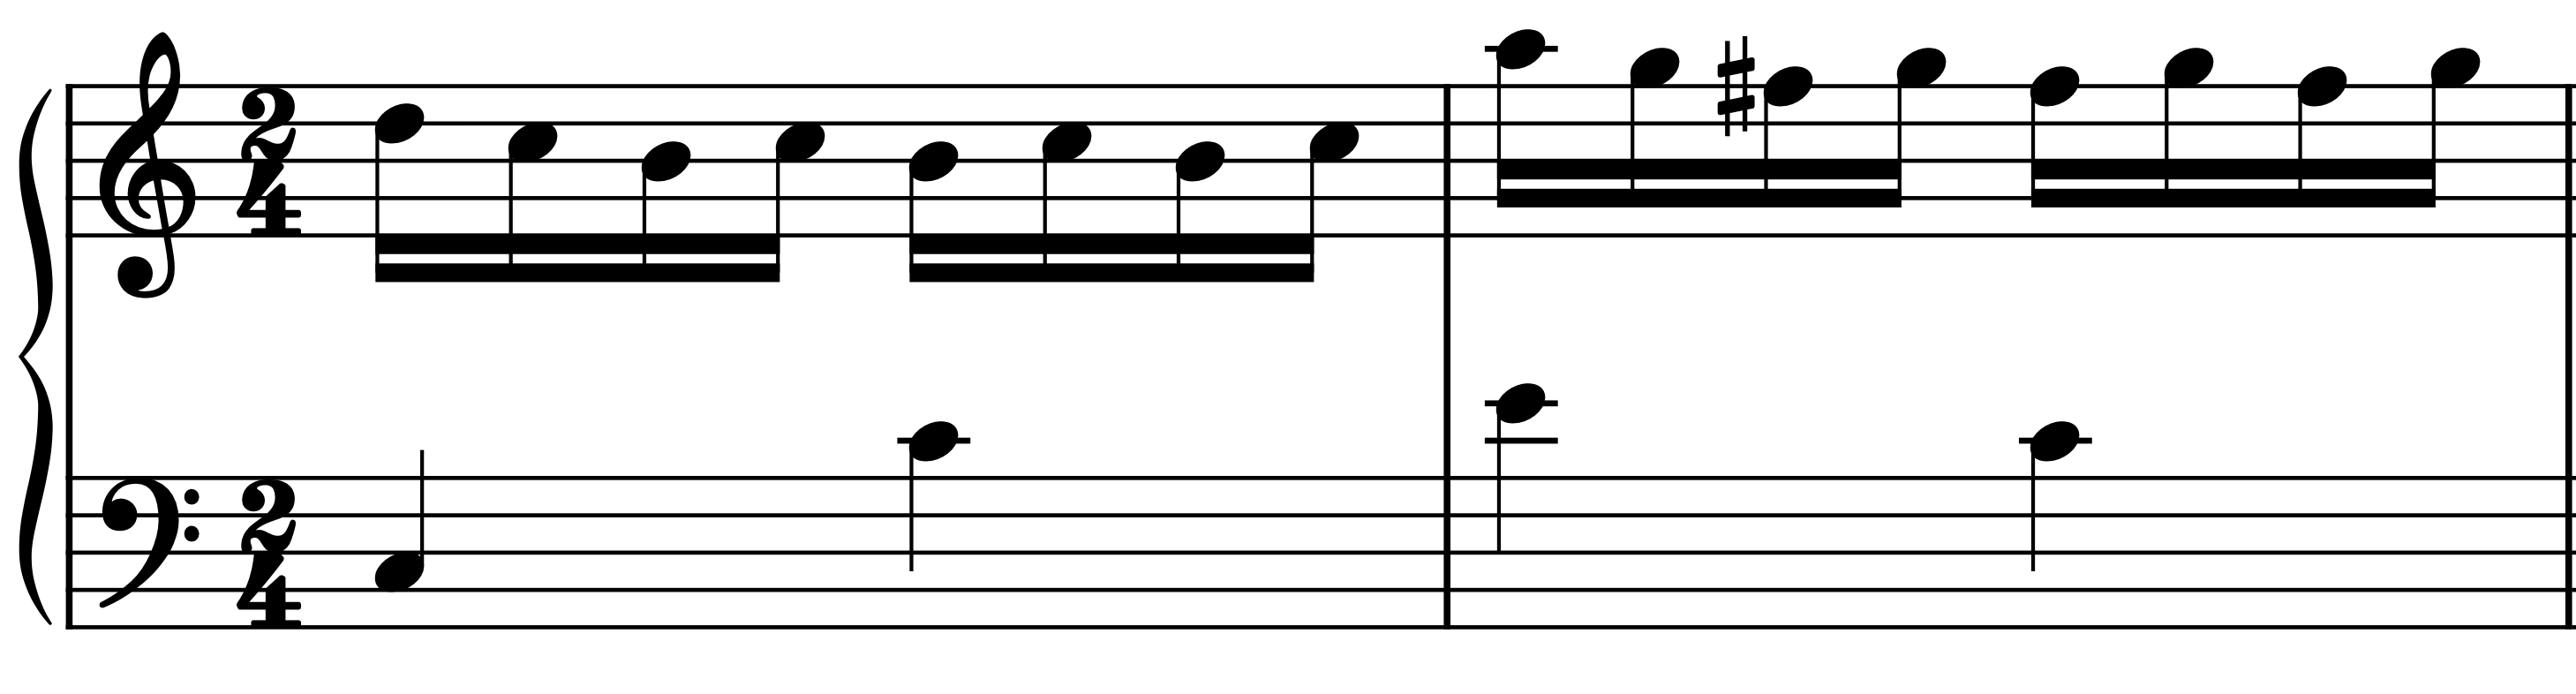

In [5]:
from IPython.display import clear_output, Audio
import matplotlib.image as mpimg

print(f"Below is the short score snippet for feature visualization, along with the audio snippet (first 2 measures).")
display(Image(filename=str(PREVIEW_IMAGE), width=700))
display(Audio(filename=str(SNIPPET_FILE)))

# Cached once: score image + its aspect ratio (used for figure sizing below).
SCORE_IMG = mpimg.imread(str(PREVIEW_IMAGE))
SCORE_AR = SCORE_IMG.shape[1] / SCORE_IMG.shape[0]


def live_stream_processor(processor, sample_rate, hop_length, title, ylabel, yticks, yticklabels):
    """Stream SNIPPET_FILE hop-by-hop through processor; grow chart one column at a time."""
    audio_y, _ = librosa.load(str(SNIPPET_FILE), sr=sample_rate, mono=True)
    rem = len(audio_y) % hop_length
    if rem:
        audio_y = np.concatenate((audio_y, np.zeros(hop_length - rem, dtype=np.float32)))
    n_hops = len(audio_y) // hop_length
    cache_size = getattr(processor, "n_fft", 2 * hop_length) - hop_length
    hop_seconds = hop_length / sample_rate
    redraw_every = max(1, n_hops // 12)

    last_chunk = None
    emit_count = 0
    feature_buffer = None

    score_h, feat_h = 2.0, 2.0
    fig, (score_ax, ax) = plt.subplots(
        2, 1,
        figsize=(SCORE_AR * score_h, score_h + feat_h),
        gridspec_kw={"height_ratios": [score_h, feat_h]},
    )
    score_ax.imshow(SCORE_IMG)
    score_ax.set_axis_off()
    score_ax.set_title("Score (first two measures)")

    for hop_idx in range(n_hops):
        chunk = audio_y[hop_idx * hop_length : (hop_idx + 1) * hop_length]
        if last_chunk is None:
            target = np.concatenate((np.zeros(cache_size, dtype=np.float32), chunk))
        else:
            target = np.concatenate((last_chunk, chunk))

        if last_chunk is not None:
            feature_block, _ = processor((target, emit_count * hop_seconds))
            feature_block = np.asarray(feature_block)
            if feature_buffer is None:
                feature_buffer = np.zeros((feature_block.shape[1], n_hops))
            n_new = feature_block.shape[0]
            feature_buffer[:, emit_count:emit_count + n_new] = feature_block.T
            emit_count += n_new

        last_chunk = target[-cache_size:]

        if hop_idx % redraw_every != 0 and hop_idx != n_hops - 1:
            continue

        ax.clear()
        if emit_count > 0:
            ax.imshow(
                feature_buffer[:, :emit_count],
                origin="lower", aspect="auto", interpolation="nearest",
                extent=[0, emit_count * hop_seconds, 0, feature_buffer.shape[0]],
                vmin=0,
            )
        ax.set_xlim(0, n_hops * hop_seconds)
        ax.set(xlabel="Performance time (s)", ylabel=ylabel, title=title)
        ax.set_yticks(yticks)
        ax.set_yticklabels(yticklabels)
        ax.grid(False)

        clear_output(wait=True)
        display(fig)

    plt.close(fig)
    processor.reset()
    return feature_buffer, emit_count

### 2-1:Chroma

`ChromagramProcessor` collapses spectral energy into 12 pitch classes (C, C#, …, B), dropping octave information. Each call takes one hop of audio and returns a 12-dim row.

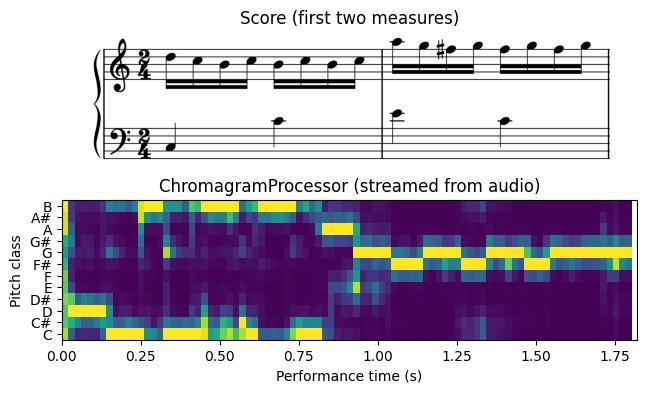

Final feature shape: (12, 90) = pitch classes x hops

Offline chroma shape: (12, 89)
Streamed (online) chroma usable shape: (12, 90)
Max |online - offline| over 89 overlapping frames: 5.92e-01


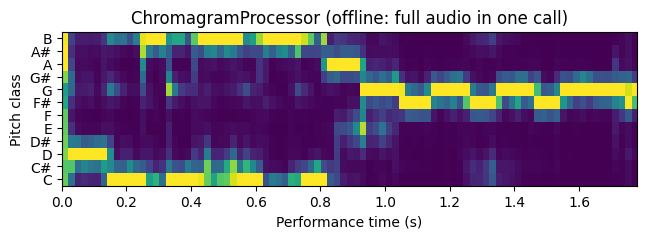

In [6]:
chroma_sr = 22050
chroma_hop = chroma_sr // 50  # 50 fps
chroma_processor = ChromagramProcessor(sample_rate=chroma_sr, hop_length=chroma_hop)
print("Processor:", chroma_processor.__class__.__name__)
print(f"  sample_rate = {chroma_sr} Hz, hop_length = {chroma_hop} samples")
print(f"  one feature row every {chroma_hop / chroma_sr * 1000:.1f} ms")

pitch_class_names = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]
pitch_yticks = np.arange(12) + 0.5

chroma_buffer, chroma_emitted = live_stream_processor(
    chroma_processor, chroma_sr, chroma_hop,
    title="ChromagramProcessor (streamed from audio)",
    ylabel="Pitch class",
    yticks=pitch_yticks,
    yticklabels=pitch_class_names,
)
print(f"Final feature shape: ({chroma_buffer.shape[0]}, {chroma_emitted}) = pitch classes x hops")

# Online vs. offline sanity check: feed the whole snippet through in one shot.
chroma_processor.reset()
full_audio, _ = librosa.load(str(SNIPPET_FILE), sr=chroma_sr, mono=True)
offline_chroma = chroma_processor((full_audio, 0.0))[0].T  # (12, n_frames)
streamed = chroma_buffer[:, :chroma_emitted]
m = min(streamed.shape[1], offline_chroma.shape[1])
print(f"\nOffline chroma shape: {offline_chroma.shape}")
print(f"Streamed (online) chroma usable shape: {streamed.shape}")
print(f"Max |online - offline| over {m} overlapping frames: {np.abs(streamed[:, :m] - offline_chroma[:, :m]).max():.2e}")

fig, ax = plt.subplots(figsize=(SCORE_AR * 2.0, 2.0))
ax.imshow(
    offline_chroma, origin="lower", aspect="auto", interpolation="nearest",
    extent=[0, offline_chroma.shape[1] * chroma_hop / chroma_sr, 0, 12], vmin=0,
)
ax.set(xlabel="Performance time (s)", ylabel="Pitch class",
       title="ChromagramProcessor (offline: full audio in one call)")
ax.set_yticks(pitch_yticks)
ax.set_yticklabels(pitch_class_names)
plt.show()

### 2-2: CQT

`CQTProcessor` returns an 88-bin constant-Q transform per hop, one bin per piano key (A0–C8). Unlike chroma, the octave is preserved — you can read off actual notes rather than just pitch classes.

The audio `outerhmm` follower uses the related `CQTSpectralFluxProcessor`, which packs the same 88 CQT bins plus a 89th spectral-flux row used as an exit-boost signal. For visualization we use the plain CQT version since the flux value lives on a very different scale (sum over 88 bins) and would dominate a shared colormap.

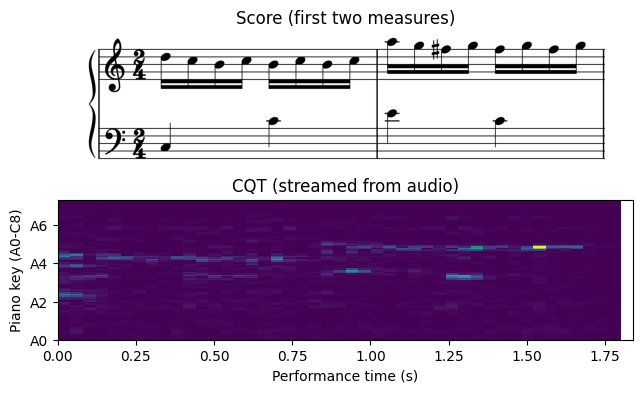

Final feature shape: (88, 45) = CQT bins x hops

Offline CQT shape: (88, 44)
Streamed (online) CQT usable shape: (88, 45)
Max |online - offline| over 44 overlapping frames: 9.95e-01


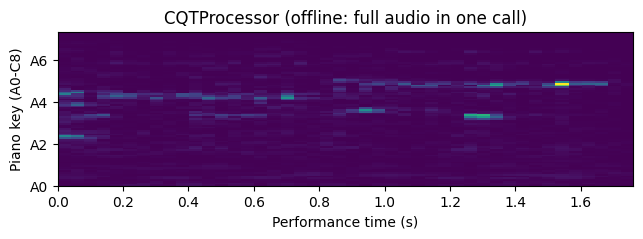

In [7]:
cqt_sr = 16000
cqt_hop = cqt_sr // 25  # 25 fps
cqt_processor = CQTProcessor(sample_rate=cqt_sr, hop_length=cqt_hop)
print("Processor:", cqt_processor.__class__.__name__)
print(f"  sample_rate = {cqt_sr} Hz, hop_length = {cqt_hop} samples")
print(f"  one feature row every {cqt_hop / cqt_sr * 1000:.1f} ms")

cqt_yticks = [0, 24, 48, 72]
cqt_yticklabels = ["A0", "A2", "A4", "A6"]

cqt_buffer, cqt_emitted = live_stream_processor(
    cqt_processor, cqt_sr, cqt_hop,
    title="CQT (streamed from audio)",
    ylabel="Piano key (A0-C8)",
    yticks=cqt_yticks,
    yticklabels=cqt_yticklabels,
)
print(f"Final feature shape: ({cqt_buffer.shape[0]}, {cqt_emitted}) = CQT bins x hops")

# Online vs. offline sanity check.
cqt_processor.reset()
full_audio_cqt, _ = librosa.load(str(SNIPPET_FILE), sr=cqt_sr, mono=True)
offline_cqt = cqt_processor((full_audio_cqt, 0.0))[0].T  # (88, n_frames)
streamed_cqt = cqt_buffer[:, :cqt_emitted]
m = min(streamed_cqt.shape[1], offline_cqt.shape[1])
print(f"\nOffline CQT shape: {offline_cqt.shape}")
print(f"Streamed (online) CQT usable shape: {streamed_cqt.shape}")
print(f"Max |online - offline| over {m} overlapping frames: {np.abs(streamed_cqt[:, :m] - offline_cqt[:, :m]).max():.2e}")

fig, ax = plt.subplots(figsize=(SCORE_AR * 2.0, 2.0))
ax.imshow(
    offline_cqt, origin="lower", aspect="auto", interpolation="nearest",
    extent=[0, offline_cqt.shape[1] * cqt_hop / cqt_sr, 0, offline_cqt.shape[0]],
    vmin=0,
)
ax.set(xlabel="Performance time (s)", ylabel="Piano key (A0-C8)",
       title="CQTProcessor (offline: full audio in one call)")
ax.set_yticks(cqt_yticks)
ax.set_yticklabels(cqt_yticklabels)
plt.show()

## 3. Matchmaker overview

For this workshop, the main object is `Matchmaker`. We use it in **simulation mode**: the input is a recorded audio or MIDI performance file, but Matchmaker feeds it through the same streaming pipeline used for real-time score following.

```python
from matchmaker import Matchmaker

mm = Matchmaker(
    score_file="path/to/score.musicxml",
    performance_file="path/to/performance.mp3",  # or .mid
    input_type="audio",                          # or "midi"
    method="arzt",                              # optional
)

for current_position in mm.run():
    print(current_position)
```

The yielded value is the estimated score position in beats. After a run, `mm.score_follower.alignment_path` stores a `(2, T)` array:

- row 0: estimated score beat
- row 1: performance time in seconds

We will use the helper functions below so that each practical example returns the same kind of result dictionary.

In [ ]:
print("Available methods:")
for input_type, methods in AVAILABLE_METHODS.items():
    print(f"  {input_type}: {methods}")

print("\nDefaults:")
print("  method:", DEFAULT_METHOD)
print("  processor:", DEFAULT_PROCESSOR)

### 3.1 Reading Matchmaker's score positions

Matchmaker reports the current position in **score beats**. For this Mozart example, the score positions come from Partitura's `note_array()` representation, especially the `onset_beat` field.

The unique note-onset beats become the main discrete score states used by several online followers.

In [ ]:
score = pt.load_musicxml(str(SCORE_FILE))
score_part = score[0]
note_array = score_part.note_array()
score_positions = np.unique(note_array["onset_beat"])

print(f"Number of notes: {len(note_array)}")
print(f"Number of unique score onset positions: {len(score_positions)}")
print("First 8 score positions in beats (first measure):")
print(score_positions[:8])

display(Image(filename=str(PREVIEW_IMAGE), width=700))

pd.DataFrame(note_array[:10])[["id", "pitch", "onset_beat", "duration_beat"]]

In [ ]:
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

print(f"Results will be saved in {RESULTS_DIR.resolve()}")


def stream_audio_features(audio_file, processor, sample_rate, hop_length):
    """Simulate Matchmaker's hop-by-hop AudioStream feature extraction."""
    audio_y, sr = librosa.load(str(audio_file), sr=None, mono=True)
    if sr != sample_rate:
        audio_y = librosa.resample(y=audio_y, orig_sr=sr, target_sr=sample_rate)

    remainder = len(audio_y) % hop_length
    if remainder > 0:
        audio_y = np.concatenate(
            (audio_y, np.zeros(hop_length - remainder, dtype=np.float32))
        )

    cache_size = getattr(processor, "n_fft", 2 * hop_length) - hop_length
    last_chunk = None
    emit_count = 0
    features = []
    times = []

    for start in range(0, len(audio_y), hop_length):
        target_audio = audio_y[start : start + hop_length]
        if last_chunk is None:
            target_audio = np.concatenate(
                (np.zeros(cache_size, dtype=np.float32), target_audio)
            )
        else:
            target_audio = np.concatenate((last_chunk, target_audio))

        perf_time = emit_count * hop_length / float(sample_rate)
        output = processor((target_audio, perf_time))

        # Matchmaker's AudioStream skips queue emission for the first padded block.
        if last_chunk is not None and output is not None:
            feature_block, feature_time = output
            feature_block = np.asarray(feature_block)
            for row_index, row in enumerate(feature_block):
                features.append(row)
                times.append(feature_time + row_index * hop_length / float(sample_rate))
            emit_count += 1

        last_chunk = target_audio[-cache_size:]

    processor.reset()
    return np.asarray(features), np.asarray(times)


## 4. Audio score following

For audio input, Matchmaker converts audio chunks into frame-based features. The default audio processor is `"chroma"`, and the default audio method is `"arzt"`.

Audio methods available in Matchmaker include:

- `"arzt"`: online time warping adapted from Arzt/Brazier and Widmer style score following.
- `"dixon"`: online time warping based on Dixon's method.
- `"outerhmm"`: outer-product HMM score follower.
- `"skf"`: switching Kalman filter with hidden tempo.

We start by inspecting chroma features from the recorded Mozart performance.

In [ ]:
sample_rate = 44100
frame_rate = 30
hop_length = sample_rate // frame_rate

chroma_processor = ChromagramProcessor(sample_rate=sample_rate, hop_length=hop_length)
chroma, chroma_times = stream_audio_features(
    AUDIO_FILE,
    processor=chroma_processor,
    sample_rate=sample_rate,
    hop_length=hop_length,
)

audio_duration = librosa.get_duration(path=str(AUDIO_FILE))

print("Audio duration:", round(audio_duration, 2), "seconds")
print("Streamed chroma shape:", chroma.shape, "= frames x pitch classes")

fig, ax = plt.subplots(figsize=(10, 4))
img = ax.imshow(
    chroma.T,
    origin="lower",
    aspect="auto",
    interpolation="nearest",
    extent=[chroma_times[0], chroma_times[-1], 0, chroma.shape[1] - 1],
)
ax.set_xlabel("Performance time (seconds)")
ax.set_ylabel("Pitch class")
ax.set_title("Audio chroma features from Matchmaker's streaming processor")
fig.colorbar(img, ax=ax, label="Feature value")
plt.show()

### 4.1 Dynamic programming / Arzt method

The dynamic-programming tracker compares each incoming audio feature frame with the reference features synthesized from the score. It updates a local cost surface and keeps a plausible online path through the score.

Because the tracker is online, it does not get to revise the whole path with future information. Local mistakes and small delays are part of the problem.

In [ ]:
print(f"Performance file: {AUDIO_FILE.name}, with input mode: audio")
print(f"Running Matchmaker with score file ({SCORE_FILE.name}) and method 'arzt'...")

audio_arzt_mm = Matchmaker(
    score_file=SCORE_FILE,
    performance_file=AUDIO_FILE,
    input_type="audio",
    method="arzt",
    processor="chroma",
)

audio_arzt_positions = []
for current_position in audio_arzt_mm.run(verbose=False):
    audio_arzt_positions.append(float(current_position))

audio_arzt_path = audio_arzt_mm.score_follower.alignment_path

print("Tracked audio observations:", len(audio_arzt_positions))
print("Audio alignment path shape:", audio_arzt_path.shape)
print("First 10 estimated beat positions:")
print(np.round(audio_arzt_positions[:10], 3))

audio_arzt_eval = audio_arzt_mm.run_evaluation(
    perf_annotations=NOTE_ANNOTATIONS,
    debug=True,
    save_dir=RESULTS_DIR,
    run_name="audio_arzt",
    level="note",
    plot_dist_matrix=False,
)

print("Evaluation result:")
print(json.dumps(audio_arzt_eval, indent=2))
display(Image(filename=str(RESULTS_DIR / "audio_arzt.png"), width=700))

### 4.2 HMM audio input features: CQT + spectral flux

The audio `outerhmm` configuration uses `processor="cqt_spectral_flux"` for the **incoming performance audio**. Compared with chroma, this representation keeps a wider pitch range and adds a spectral-flux component that emphasizes frame-to-frame changes.

Important distinction: this is the observation feature stream, not the score reference representation. For audio `outerhmm`, `Matchmaker.preprocess_score()` passes the score `note_array()` to `AudioOuterProductHMM`, and the HMM builds symbolic chord/harmonic masks from the score states.

For visualization, we compute the spectral flux directly from the CQT magnitude matrix and append it as the last row. This mirrors the idea of the streaming processor while making the feature visible in one static notebook plot.

In [ ]:
outerhmm_sample_rate = 16000
outerhmm_frame_rate = 25
outerhmm_hop_length = outerhmm_sample_rate // outerhmm_frame_rate

cqt_flux_processor = CQTSpectralFluxProcessor(
    sample_rate=outerhmm_sample_rate,
    hop_length=outerhmm_hop_length,
)
cqt_flux, cqt_flux_times = stream_audio_features(
    AUDIO_FILE,
    processor=cqt_flux_processor,
    sample_rate=outerhmm_sample_rate,
    hop_length=outerhmm_hop_length,
)

cqt_mag = cqt_flux[:, :88]
spectral_flux = cqt_flux[:, 88] if cqt_flux.shape[1] > 88 else np.zeros(len(cqt_flux))

# Normalize only for display so the flux row is visible beside CQT bins.
cqt_display = cqt_mag / (np.max(cqt_mag) + 1e-8)
flux_display = spectral_flux / (np.max(spectral_flux) + 1e-8)
combined_display = np.vstack([cqt_display.T, flux_display[None, :]])

print("Streamed CQT + spectral flux shape:", cqt_flux.shape, "= frames x feature bins")
print("CQT bins:", cqt_mag.shape[1])
print("Spectral flux max:", float(np.max(spectral_flux)))
print("Combined display shape:", combined_display.shape, "= feature rows x frames")

fig, ax = plt.subplots(figsize=(10, 5))
img = ax.imshow(
    combined_display,
    origin="lower",
    aspect="auto",
    interpolation="nearest",
    extent=[cqt_flux_times[0], cqt_flux_times[-1], 0, combined_display.shape[0] - 1],
)
ax.axhline(cqt_mag.shape[1] - 0.5, color="white", linewidth=1.0)
ax.set_xlabel("Performance time (seconds)")
ax.set_ylabel("Feature row")
ax.set_title("OuterHMM input features from Matchmaker's streaming processor")
ax.set_yticks([0, 24, 48, 72, 88])
ax.set_yticklabels(["CQT 0", "CQT 24", "CQT 48", "CQT 72", "Flux"])
fig.colorbar(img, ax=ax, label="Normalized feature value")
plt.show()

# The score reference for audio OuterHMM is symbolic, not CQT.
# Build a lightweight OuterHMM instance to inspect its score-state harmonic masks.
reference_probe_mm = Matchmaker(
    score_file=SCORE_FILE,
    performance_file=AUDIO_FILE,
    input_type="audio",
    method="outerhmm",
)
reference_harmonic_mask = reference_probe_mm.score_follower.chord_harmonic_mask
print(
    "Reference harmonic mask shape:",
    reference_harmonic_mask.shape,
    "= score states x piano keys",
)

fig, ax = plt.subplots(figsize=(10, 4))
img = ax.imshow(
    reference_harmonic_mask.T,
    origin="lower",
    aspect="auto",
    interpolation="nearest",
)
ax.set_xlabel("Score state / chord onset index")
ax.set_ylabel("Piano key index (A0-C8)")
ax.set_title("OuterHMM reference representation: score harmonic masks")
fig.colorbar(img, ax=ax, label="Normalized score-state weight")
plt.show()

### 4.3 HMM / outer-product method

The audio OuterHMM treats the current score position as a hidden state. The reference side is symbolic: the score note array is converted into one harmonic mask per score onset. The observation side is audio: each incoming frame is represented as CQT + spectral flux.

During inference, the CQT part of the observation is compared with each score-state harmonic mask. The spectral-flux value is used as an exit boost, making state changes more likely around acoustic changes.

In [ ]:
audio_outerhmm_mm = None
audio_outerhmm_positions = []
audio_outerhmm_path = None
audio_outerhmm_eval = None

try:
    print(f"Performance file: {AUDIO_FILE.name}, with input mode: audio")
    print(f"Running Matchmaker with score file ({SCORE_FILE.name}) and method 'outerhmm'...")

    audio_outerhmm_mm = Matchmaker(
        score_file=SCORE_FILE,
        performance_file=AUDIO_FILE,
        input_type="audio",
        method="outerhmm",
    )

    for current_position in audio_outerhmm_mm.run(verbose=False):
        audio_outerhmm_positions.append(float(current_position))

    audio_outerhmm_path = audio_outerhmm_mm.score_follower.alignment_path

    print("Tracked audio observations:", len(audio_outerhmm_positions))
    print("OuterHMM alignment path shape:", audio_outerhmm_path.shape)
    print("First 10 estimated beat positions:")
    print(np.round(audio_outerhmm_positions[:10], 3))

    audio_outerhmm_eval = audio_outerhmm_mm.run_evaluation(
        perf_annotations=NOTE_ANNOTATIONS,
        debug=True,
        save_dir=RESULTS_DIR,
        run_name="audio_outerhmm",
        level="note",
        plot_dist_matrix=False,
    )

    print("Evaluation result:")
    print(json.dumps(audio_outerhmm_eval, indent=2))
    display(Image(filename=str(RESULTS_DIR / "audio_outerhmm.png"), width=700))


except Exception as exc:
    print("OuterHMM audio demo skipped:")
    print(type(exc).__name__, exc)

### 4.4 Audio evaluation and method comparison

Now that the DP/Arzt and HMM-style runs have each been inspected independently, we can compare their evaluation metrics in one table.

`run_examples.py` uses `mm.run_evaluation(debug=True, save_dir=..., run_name=...)` after the score follower finishes. The cells above follow the same pattern directly: each completed `Matchmaker` run calls `mm.run_evaluation(...)`, saving alignment paths, ground-truth annotation pairs, JSON metrics, and Matchmaker debug plots into `results/`.

In [ ]:
audio_eval_items = [
    ("arzt + chroma", len(audio_arzt_positions), audio_arzt_eval),
]

if audio_outerhmm_eval is not None:
    audio_eval_items.append(
        ("outerhmm + cqt_spectral_flux", len(audio_outerhmm_positions), audio_outerhmm_eval)
    )

audio_eval_rows = []
for method, observations, evaluation in audio_eval_items:
    row = {"method": method, "observations": observations}
    for key, value in evaluation.items():
        if isinstance(value, dict):
            for subkey, subvalue in value.items():
                row[f"{key}.{subkey}"] = subvalue
        else:
            row[key] = value
    audio_eval_rows.append(row)

pd.DataFrame(audio_eval_rows)

## 5. MIDI score following

For MIDI input, the observations are symbolic note events rather than audio frames. This changes the feature representation and the error model.

MIDI methods available in Matchmaker include:

- `"pthmm"`: pitch-based HMM score follower. This is the default for MIDI.
- `"hmm"`: HMM using pitch and inter-onset information.
- `"outerhmm"`: outer-product HMM for symbolic input.
- `"arzt"` and `"dixon"`: event-based online time warping variants.

The default MIDI processor is `"pitch_chord"`, which groups near-simultaneous note events into chord observations.

In [ ]:
performance = pt.load_performance_midi(str(MIDI_FILE))
performance_notes = performance.note_array()

print("Number of performed MIDI notes:", len(performance_notes))
print("Performance note-array fields:", performance_notes.dtype.names)

midi_pianoroll, midi_onsets = onset_pianoroll(
    performance_notes,
    onset_key="onset_sec",
    piano_range=True,
)

fig, ax = plt.subplots(figsize=(10, 4))
img = ax.imshow(midi_pianoroll.T, origin="lower", aspect="auto", interpolation="nearest")
ax.set_xlabel("Chord/event index")
ax.set_ylabel("Piano key index (A0-C8)")
ax.set_title("MIDI onset piano-roll features")
fig.colorbar(img, ax=ax, label="Active pitch")
plt.show()

pd.DataFrame(performance_notes[:10])[["pitch", "onset_sec", "duration_sec"]]

### 5.1 PitchHMM

`pthmm` is the default MIDI method. It uses pitch observations and a probabilistic state model to estimate which score onset is currently active.

In [ ]:
print(f"Performance file: {MIDI_FILE.name}, with input mode: midi")
print(f"Running Matchmaker with score file ({SCORE_FILE.name}) and method 'pthmm'...")

midi_pthmm_mm = Matchmaker(
    score_file=SCORE_FILE,
    performance_file=MIDI_FILE,
    input_type="midi",
    method="pthmm",
)

midi_pthmm_positions = []
for current_position in midi_pthmm_mm.run(verbose=False):
    midi_pthmm_positions.append(float(current_position))

midi_pthmm_path = midi_pthmm_mm.score_follower.alignment_path

print("MIDI observations:", len(midi_pthmm_positions))
print("Alignment path shape:", midi_pthmm_path.shape)
print("First 10 estimated beat positions:")
print(np.round(midi_pthmm_positions[:10], 3))

midi_pthmm_eval = midi_pthmm_mm.run_evaluation(
    perf_annotations=NOTE_ANNOTATIONS,
    debug=True,
    save_dir=RESULTS_DIR,
    run_name="midi_pthmm",
    level="note",
    plot_dist_matrix=False,
)

print("Evaluation result:")
print(json.dumps(midi_pthmm_eval, indent=2))
display(Image(filename=str(RESULTS_DIR / "midi_pthmm.png"), width=700))

### 5.2 OuterHMM

Now run the symbolic OuterHMM separately. Keeping this plot separate from PitchHMM makes it easier to inspect the path shape and any failures.

In [ ]:
midi_outerhmm_mm = None
midi_outerhmm_positions = []
midi_outerhmm_path = None
midi_outerhmm_eval = None

try:
    print(f"Performance file: {MIDI_FILE.name}, with input mode: midi")
    print(f"Running Matchmaker with score file ({SCORE_FILE.name}) and method 'outerhmm'...")

    midi_outerhmm_mm = Matchmaker(
        score_file=SCORE_FILE,
        performance_file=MIDI_FILE,
        input_type="midi",
        method="outerhmm",
    )

    for current_position in midi_outerhmm_mm.run(verbose=False):
        midi_outerhmm_positions.append(float(current_position))

    midi_outerhmm_path = midi_outerhmm_mm.score_follower.alignment_path

    print("MIDI OuterHMM observations:", len(midi_outerhmm_positions))
    print("Alignment path shape:", midi_outerhmm_path.shape)
    print("First 10 estimated beat positions:")
    print(np.round(midi_outerhmm_positions[:10], 3))

    midi_outerhmm_eval = midi_outerhmm_mm.run_evaluation(
        perf_annotations=NOTE_ANNOTATIONS,
        debug=True,
        save_dir=RESULTS_DIR,
        run_name="midi_outerhmm",
        level="note",
        plot_dist_matrix=False,
    )

    print("Evaluation result:")
    print(json.dumps(midi_outerhmm_eval, indent=2))
    display(Image(filename=str(RESULTS_DIR / "midi_outerhmm.png"), width=700))
except Exception as exc:
    print("MIDI OuterHMM demo skipped:")
    print(type(exc).__name__, exc)

## 6. MIDI evaluation

Compare the MIDI PitchHMM and MIDI OuterHMM evaluation metrics in one table.

In [ ]:
midi_eval_items = [
    ("midi pthmm", len(midi_pthmm_positions), midi_pthmm_eval),
]

if midi_outerhmm_eval is not None:
    midi_eval_items.append(
        ("midi outerhmm", len(midi_outerhmm_positions), midi_outerhmm_eval)
    )

midi_eval_rows = []
for method, observations, evaluation in midi_eval_items:
    row = {"method": method, "observations": observations}
    for key, value in evaluation.items():
        if isinstance(value, dict):
            for subkey, subvalue in value.items():
                row[f"{key}.{subkey}"] = subvalue
        else:
            row[key] = value
    midi_eval_rows.append(row)

pd.DataFrame(midi_eval_rows)

## 7. Practical variations

Small changes to try during the workshop:

Audio:

- Change the audio method from `"arzt"` to `"dixon"`.
- Change the audio processor from `"chroma"` to `"mfcc"`, `"cqt"`, or `"mel"`.
- Inspect the saved files in `results/`: alignment path TSV, ground-truth TSV, JSON metrics, and debug plot.

MIDI:

- Try MIDI `"hmm"` or `"arzt"` in the playground cell and inspect each plot separately.
- Look for places where symbolic methods react differently to event grouping or pitch errors.

The important thing to watch is not only whether a final alignment looks correct, but how quickly and stably the online estimate moves while the performance unfolds.

In [ ]:
# Example playground cell.
# Edit these values and rerun.

PLAY_INPUT_TYPE = "audio"   # "audio" or "midi"
PLAY_METHOD = "dixon"       # audio: "arzt", "dixon", "outerhmm"; midi: "pthmm", "hmm", "outerhmm", "arzt"
PLAY_PROCESSOR = None        # e.g. "chroma", "mfcc", "cqt", "mel" for audio

performance_file = AUDIO_FILE if PLAY_INPUT_TYPE == "audio" else MIDI_FILE
run_name = f"playground_{PLAY_INPUT_TYPE}_{PLAY_METHOD}"

try:
    playground_mm = Matchmaker(
        score_file=SCORE_FILE,
        performance_file=performance_file,
        input_type=PLAY_INPUT_TYPE,
        method=PLAY_METHOD,
        processor=PLAY_PROCESSOR,
    )
    playground_positions = []
    for current_position in playground_mm.run(verbose=False):
        playground_positions.append(float(current_position))

    playground_eval = playground_mm.run_evaluation(
        perf_annotations=NOTE_ANNOTATIONS,
        debug=True,
        save_dir=RESULTS_DIR,
        run_name=run_name,
        level="note",
        plot_dist_matrix=False,
    )

    print("Tracked observations:", len(playground_positions))
    print("Evaluation result:")
    print(json.dumps(playground_eval, indent=2))
    display(Image(filename=str(RESULTS_DIR / f"{run_name}.png"), width=700))
except Exception as exc:
    print("Playground run failed:")
    print(type(exc).__name__, exc)

## 8. Optional extension: where custom score followers plug in

This is not the main workshop path. The practical priority is to run and compare the existing Matchmaker followers above.

If you later want to add a new online alignment method, the core interface is small: subclass `matchmaker.base.OnlineAlignment`, implement `step(features)`, and update `self.current_index`. Matchmaker's base class handles `__call__`, `run()`, and `alignment_path` bookkeeping.

The tiny example below is intentionally naive: it ignores the input features and simply advances one score state per observation. Its purpose is only to show the interface described in `HOW_TO_MAKE_CUSTOM_SCORE_FOLLOWERS.md`.

In [ ]:
from matchmaker.base import OnlineAlignment

class StepThroughFollower(OnlineAlignment):
    def step(self, features):
        self.current_index = min(
            self.current_index + 1,
            len(self.score_positions) - 1,
        )

toy_follower = StepThroughFollower(score_positions=score_positions)

for i in range(8):
    beat = toy_follower((None, i * 0.25))
    print(f"observation {i:02d}: estimated score beat = {beat:.2f}")

print("Toy alignment path shape:", toy_follower.alignment_path.shape)